<a href="https://colab.research.google.com/github/Ayon150/AI_-_DL/blob/main/DL_ASSIGNMENT_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.0 MB/s eta 0:00:00
Device: cuda


100%|██████████| 170M/170M [10:59<00:00, 258kB/s]



Training Started...

Epoch [1/5] Loss: 1.4726
Epoch [2/5] Loss: 1.0217
Epoch [3/5] Loss: 0.8149
Epoch [4/5] Loss: 0.6814
Epoch [5/5] Loss: 0.5532

Training Finished!

True Label : horse
Prediction : horse


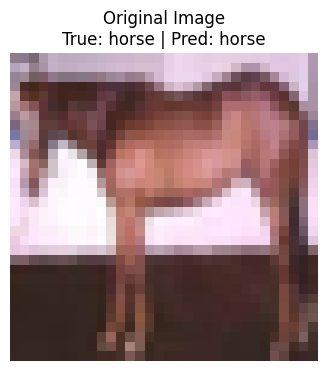

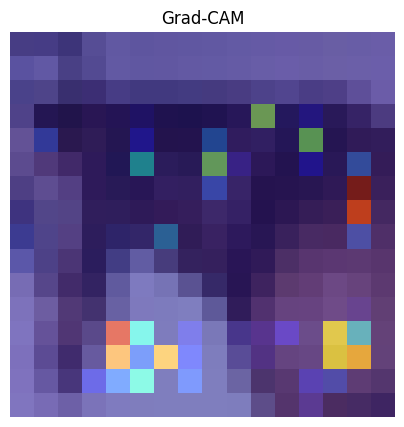

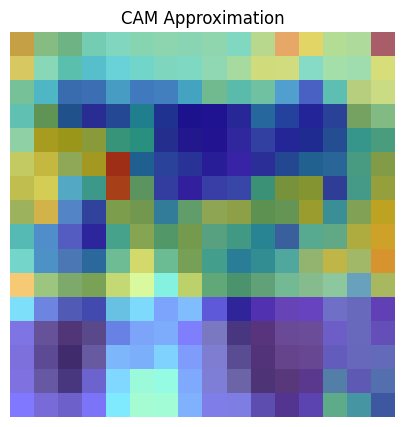

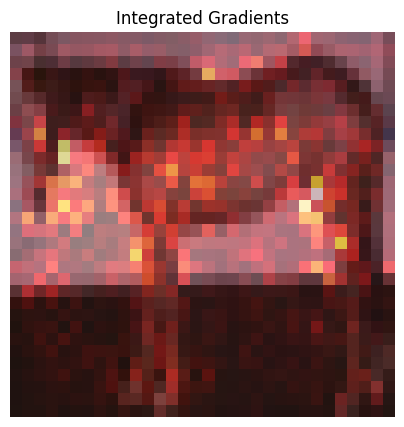


Model saved as cnn_cifar10.pth


In [1]:
# ==========================================================
# COLAB READY - CNN EXPLAINABILITY ON CIFAR-10
# CAM, Grad-CAM, Integrated Gradients
# ==========================================================

# ==========================================================
# INSTALLS
# ==========================================================
!pip -q install captum

# ==========================================================
# IMPORTS
# ==========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================================================
# CIFAR-10 DATASET
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=1,
    shuffle=True
)

classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# ==========================================================
# SIMPLE CNN MODEL
# ==========================================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)

# ==========================================================
# TRAINING
# ==========================================================
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

print("\nTraining Started...\n")

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")

print("\nTraining Finished!")

# ==========================================================
# TEST IMAGE
# ==========================================================
model.eval()

images, labels = next(iter(testloader))

image = images.to(device)
label = labels.item()

with torch.no_grad():
    output = model(image)
    pred = torch.argmax(output, dim=1).item()

print("\nTrue Label :", classes[label])
print("Prediction :", classes[pred])

# ==========================================================
# SHOW ORIGINAL IMAGE
# ==========================================================
img_np = image.squeeze().permute(1,2,0).cpu().numpy()

plt.figure(figsize=(4,4))
plt.imshow(img_np)
plt.title(f"Original Image\nTrue: {classes[label]} | Pred: {classes[pred]}")
plt.axis("off")
plt.show()

# ==========================================================
# GRAD-CAM
# ==========================================================
gradients = []
activations = []

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

def forward_hook(module, input, output):
    activations.append(output)

target_layer = model.features[4]

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# Forward pass
output = model(image)

pred_class = output.argmax(dim=1)

# Backward
model.zero_grad()
output[0, pred_class].backward()

# Get gradients and activations
grads = gradients[0]
acts = activations[0]

weights = grads.mean(dim=(2,3), keepdim=True)

cam = (weights * acts).sum(dim=1).squeeze()

cam = F.relu(cam)

cam -= cam.min()
cam /= cam.max()

cam = cam.detach().cpu().numpy()

# ==========================================================
# SHOW GRAD-CAM
# ==========================================================
plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")
plt.show()

# ==========================================================
# CLASS ACTIVATION MAP (CAM)
# ==========================================================
# Simplified CAM-like visualization using feature maps

feature_maps = acts.squeeze().detach().cpu().numpy()

avg_map = np.mean(feature_maps, axis=0)

avg_map -= avg_map.min()
avg_map /= avg_map.max()

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(avg_map, cmap='jet', alpha=0.5)
plt.title("CAM Approximation")
plt.axis("off")
plt.show()

# ==========================================================
# INTEGRATED GRADIENTS
# ==========================================================
ig = IntegratedGradients(model)

attributions, delta = ig.attribute(
    image,
    target=pred_class.item(),
    return_convergence_delta=True
)

attr = attributions.squeeze().cpu().detach().numpy()

attr = np.transpose(attr, (1,2,0))

attr = np.mean(np.abs(attr), axis=2)

attr -= attr.min()
attr /= attr.max()

# ==========================================================
# SHOW INTEGRATED GRADIENTS
# ==========================================================
plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(attr, cmap='hot', alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================
torch.save(model.state_dict(), "cnn_cifar10.pth")

print("\nModel saved as cnn_cifar10.pth")

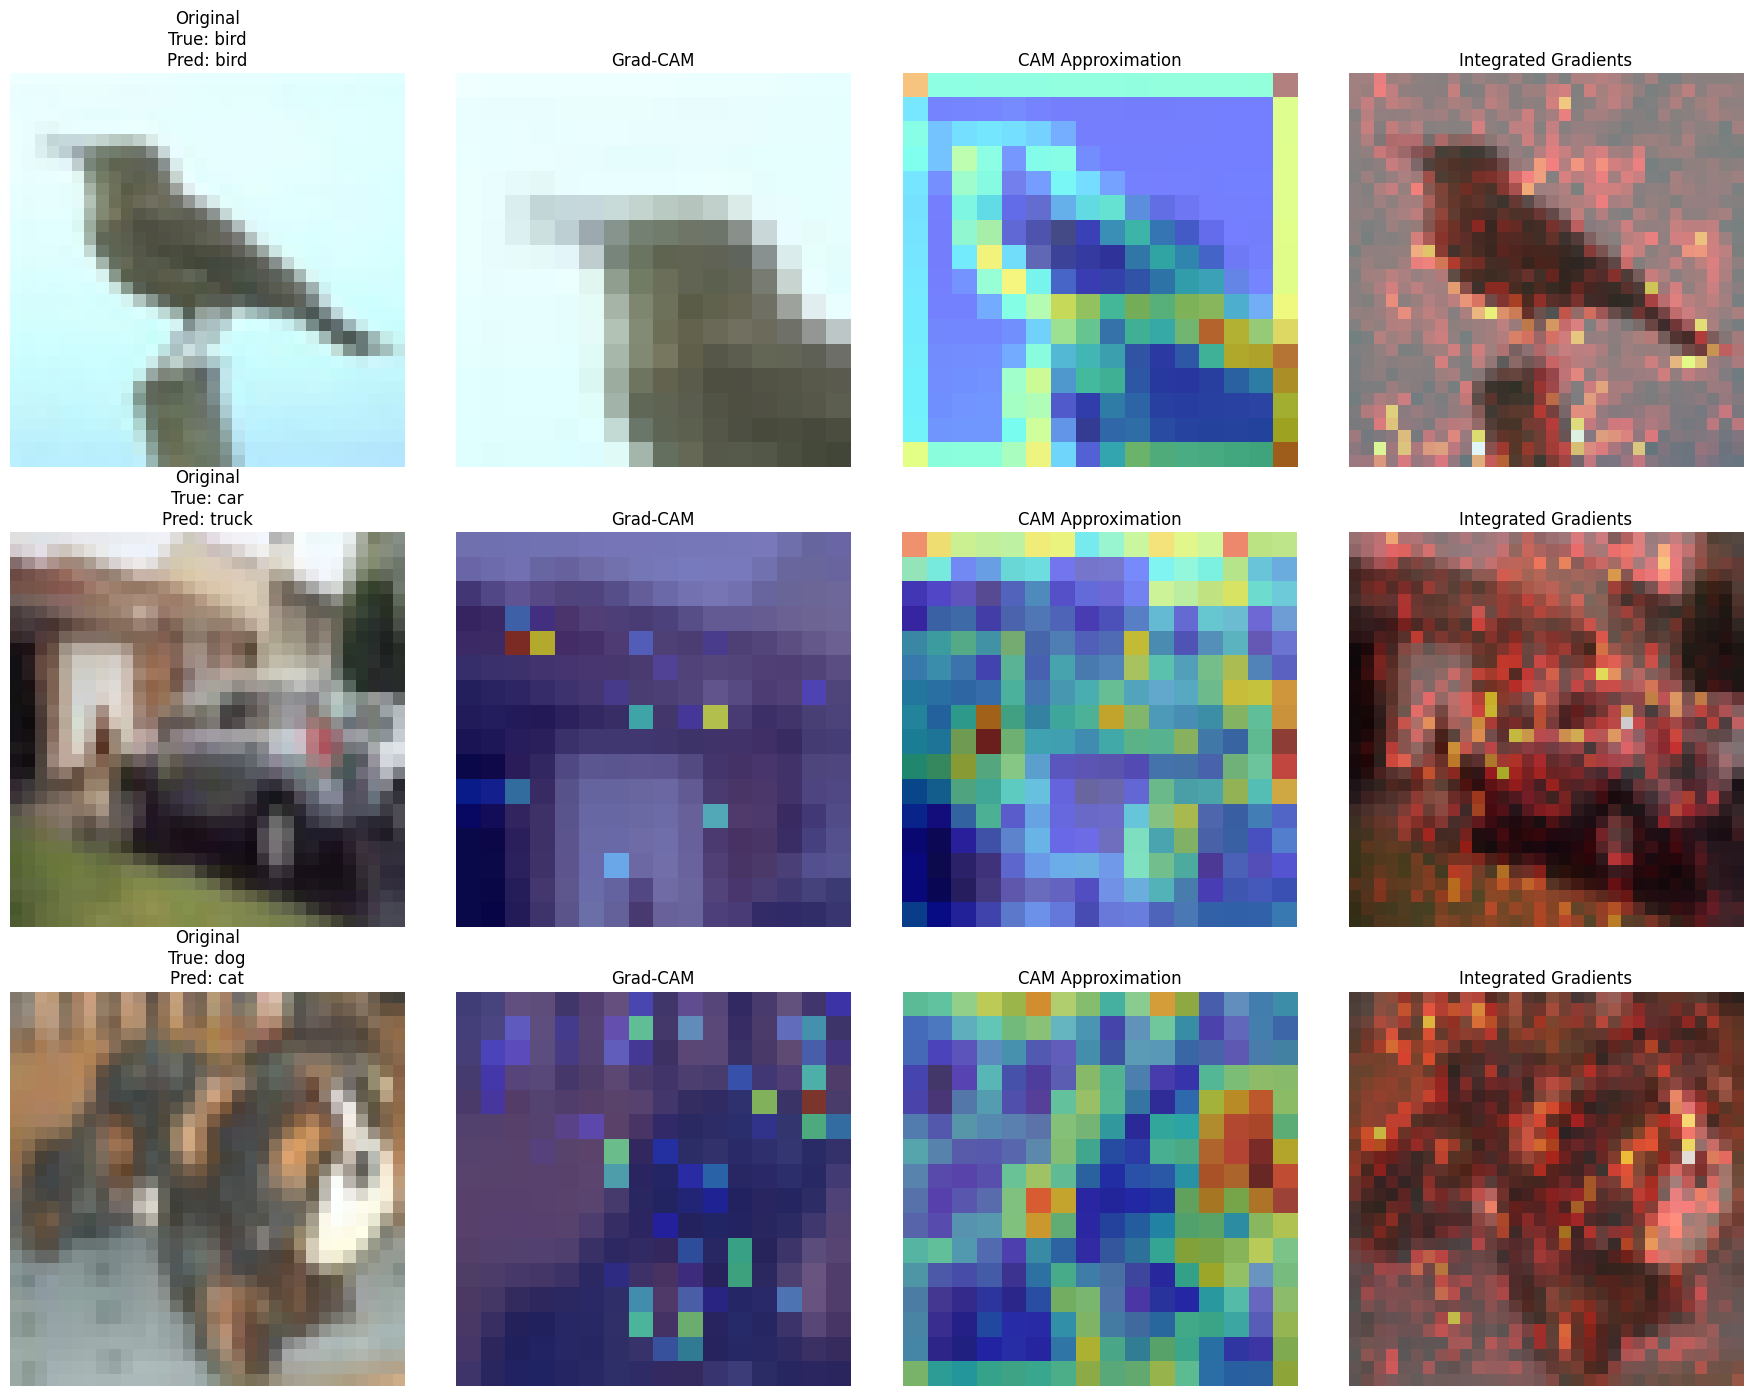

In [2]:
# ==========================================================
# SHOW 3 PREDICTIONS + EXPLAINABILITY
# ==========================================================

model.eval()

# Get 3 images
dataiter = iter(testloader)

images_list = []
labels_list = []

for _ in range(3):
    img, lbl = next(dataiter)
    images_list.append(img)
    labels_list.append(lbl)

# ==========================================================
# VISUALIZE
# ==========================================================

fig, axes = plt.subplots(3, 4, figsize=(18, 14))

for idx in range(3):

    image = images_list[idx].to(device)
    label = labels_list[idx].item()

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------
    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, dim=1).item()

    img_np = image.squeeze().permute(1,2,0).cpu().numpy()

    # ======================================================
    # ORIGINAL IMAGE
    # ======================================================
    axes[idx,0].imshow(img_np)
    axes[idx,0].set_title(
        f"Original\nTrue: {classes[label]}\nPred: {classes[pred]}"
    )
    axes[idx,0].axis("off")

    # ======================================================
    # GRAD-CAM
    # ======================================================
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_layer = model.features[4]

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(image)

    pred_class = output.argmax(dim=1)

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)

    cam = (weights * acts).sum(dim=1).squeeze()

    cam = F.relu(cam)

    cam -= cam.min()
    cam /= cam.max()

    cam = cam.detach().cpu().numpy()

    axes[idx,1].imshow(img_np)
    axes[idx,1].imshow(cam, cmap='jet', alpha=0.5)
    axes[idx,1].set_title("Grad-CAM")
    axes[idx,1].axis("off")

    # Remove hooks
    fh.remove()
    bh.remove()

    # ======================================================
    # CAM APPROXIMATION
    # ======================================================
    feature_maps = acts.squeeze().detach().cpu().numpy()

    avg_map = np.mean(feature_maps, axis=0)

    avg_map -= avg_map.min()
    avg_map /= avg_map.max()

    axes[idx,2].imshow(img_np)
    axes[idx,2].imshow(avg_map, cmap='jet', alpha=0.5)
    axes[idx,2].set_title("CAM Approximation")
    axes[idx,2].axis("off")

    # ======================================================
    # INTEGRATED GRADIENTS
    # ======================================================
    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        image,
        target=pred_class.item(),
        return_convergence_delta=True
    )

    attr = attributions.squeeze().cpu().detach().numpy()

    attr = np.transpose(attr, (1,2,0))

    attr = np.mean(np.abs(attr), axis=2)

    attr -= attr.min()
    attr /= attr.max()

    axes[idx,3].imshow(img_np)
    axes[idx,3].imshow(attr, cmap='hot', alpha=0.5)
    axes[idx,3].set_title("Integrated Gradients")
    axes[idx,3].axis("off")

plt.tight_layout()
plt.show()

Device: cuda


Saving face.zip to face (1).zip
Dataset Extracted!
Classes: ['al-amin', 'ayon', 'aziz', 'ena', 'mohon', 'washima']
Total Images: 30

Training Started...

Epoch [1/10] Loss: 2.0501
Epoch [2/10] Loss: 1.7551
Epoch [3/10] Loss: 1.7388
Epoch [4/10] Loss: 1.5915
Epoch [5/10] Loss: 1.3317
Epoch [6/10] Loss: 1.0051
Epoch [7/10] Loss: 0.5042
Epoch [8/10] Loss: 0.1953
Epoch [9/10] Loss: 0.0493
Epoch [10/10] Loss: 0.0315

Training Finished!


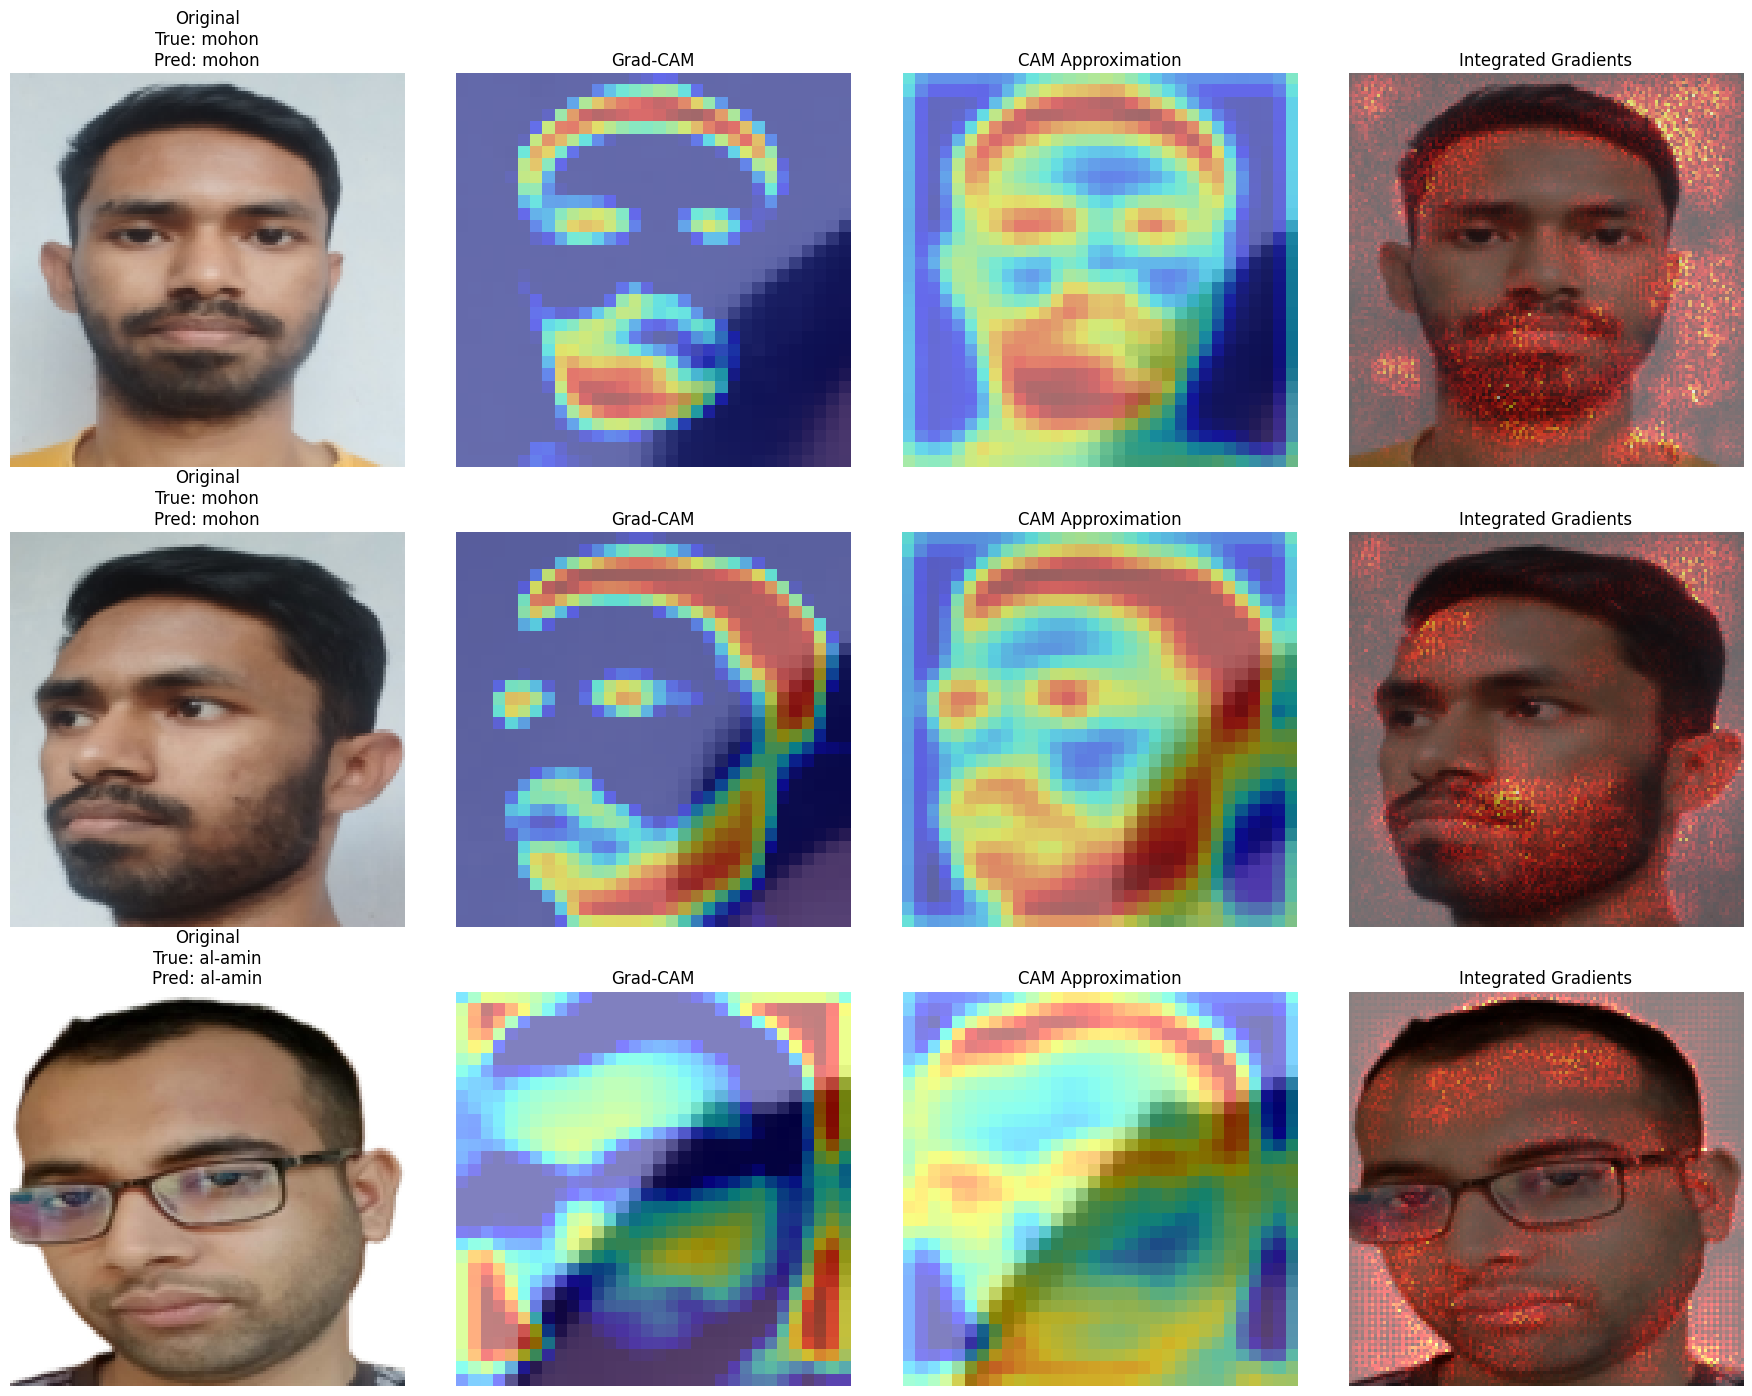


Model Saved!


In [5]:
# ==========================================================
# OWN FACE DATASET + CNN + CAM + GRAD-CAM + IG
# COLAB READY
# ==========================================================

# ==========================================================
# STEP 1:
# Upload your dataset ZIP
#
# Example structure:
#
# face_dataset/
# ├── ayon/
# │   ├── 1.jpg
# │   ├── 2.jpg
# │   └── ...
# ├── rahim/
# │   ├── 1.jpg
# │   ├── 2.jpg
# │   └── ...
#
# Each folder = one person/class
# ==========================================================

!pip -q install captum

# ==========================================================
# IMPORTS
# ==========================================================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from captum.attr import IntegratedGradients

from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================================================
# UPLOAD ZIP
# ==========================================================
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

# ==========================================================
# EXTRACT DATASET
# ==========================================================
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted!")

# ==========================================================
# DATASET PATH
# Change this if needed
# ==========================================================
dataset_path = "/content/face"

# ==========================================================
# TRANSFORMS
# ==========================================================
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

# ==========================================================
# LOAD DATASET
# ==========================================================
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

class_names = dataset.classes

print("Classes:", class_names)
print("Total Images:", len(dataset))

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

# ==========================================================
# SIMPLE FACE CNN
# ==========================================================
class FaceCNN(nn.Module):

    def __init__(self, num_classes):
        super(FaceCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

model = FaceCNN(len(class_names)).to(device)

# ==========================================================
# LOSS + OPTIMIZER
# ==========================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# ==========================================================
# TRAINING
# ==========================================================
epochs = 10

print("\nTraining Started...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

print("\nTraining Finished!")

# ==========================================================
# SHOW 3 TEST PREDICTIONS
# ==========================================================
model.eval()

fig, axes = plt.subplots(3,4, figsize=(18,14))

dataiter = iter(test_loader)

for idx in range(3):

    image, label = next(dataiter)

    image = image.to(device)

    true_label = class_names[label.item()]

    # ======================================================
    # PREDICTION
    # ======================================================
    with torch.no_grad():

        output = model(image)

        pred = torch.argmax(output, dim=1).item()

    pred_label = class_names[pred]

    img_np = image.squeeze().permute(1,2,0).cpu().numpy()

    # ======================================================
    # ORIGINAL
    # ======================================================
    axes[idx,0].imshow(img_np)

    axes[idx,0].set_title(
        f"Original\nTrue: {true_label}\nPred: {pred_label}"
    )

    axes[idx,0].axis("off")

    # ======================================================
    # GRAD-CAM
    # ======================================================
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_layer = model.features[6]

    fh = target_layer.register_forward_hook(forward_hook)

    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(image)

    pred_class = output.argmax(dim=1)

    model.zero_grad()

    output[0, pred_class].backward()

    grads = gradients[0]

    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)

    cam = (weights * acts).sum(dim=1).squeeze()

    cam = F.relu(cam)

    cam -= cam.min()

    cam /= cam.max()

    cam = cam.detach().cpu().numpy()

    axes[idx,1].imshow(img_np)

    axes[idx,1].imshow(cam, cmap='jet', alpha=0.5)

    axes[idx,1].set_title("Grad-CAM")

    axes[idx,1].axis("off")

    fh.remove()
    bh.remove()

    # ======================================================
    # CAM APPROXIMATION
    # ======================================================
    feature_maps = acts.squeeze().detach().cpu().numpy()

    avg_map = np.mean(feature_maps, axis=0)

    avg_map -= avg_map.min()

    avg_map /= avg_map.max()

    axes[idx,2].imshow(img_np)

    axes[idx,2].imshow(avg_map, cmap='jet', alpha=0.5)

    axes[idx,2].set_title("CAM Approximation")

    axes[idx,2].axis("off")

    # ======================================================
    # INTEGRATED GRADIENTS
    # ======================================================
    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        image,
        target=pred_class.item(),
        return_convergence_delta=True
    )

    attr = attributions.squeeze().cpu().detach().numpy()

    attr = np.transpose(attr, (1,2,0))

    attr = np.mean(np.abs(attr), axis=2)

    attr -= attr.min()

    attr /= attr.max()

    axes[idx,3].imshow(img_np)

    axes[idx,3].imshow(attr, cmap='hot', alpha=0.5)

    axes[idx,3].set_title("Integrated Gradients")

    axes[idx,3].axis("off")

plt.tight_layout()

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================
torch.save(model.state_dict(), "face_cnn_model.pth")

print("\nModel Saved!")

In [5]:
import os

print(os.listdir('/content/face'))

['ena', 'al-amin', 'aziz', 'washima', 'ayon']


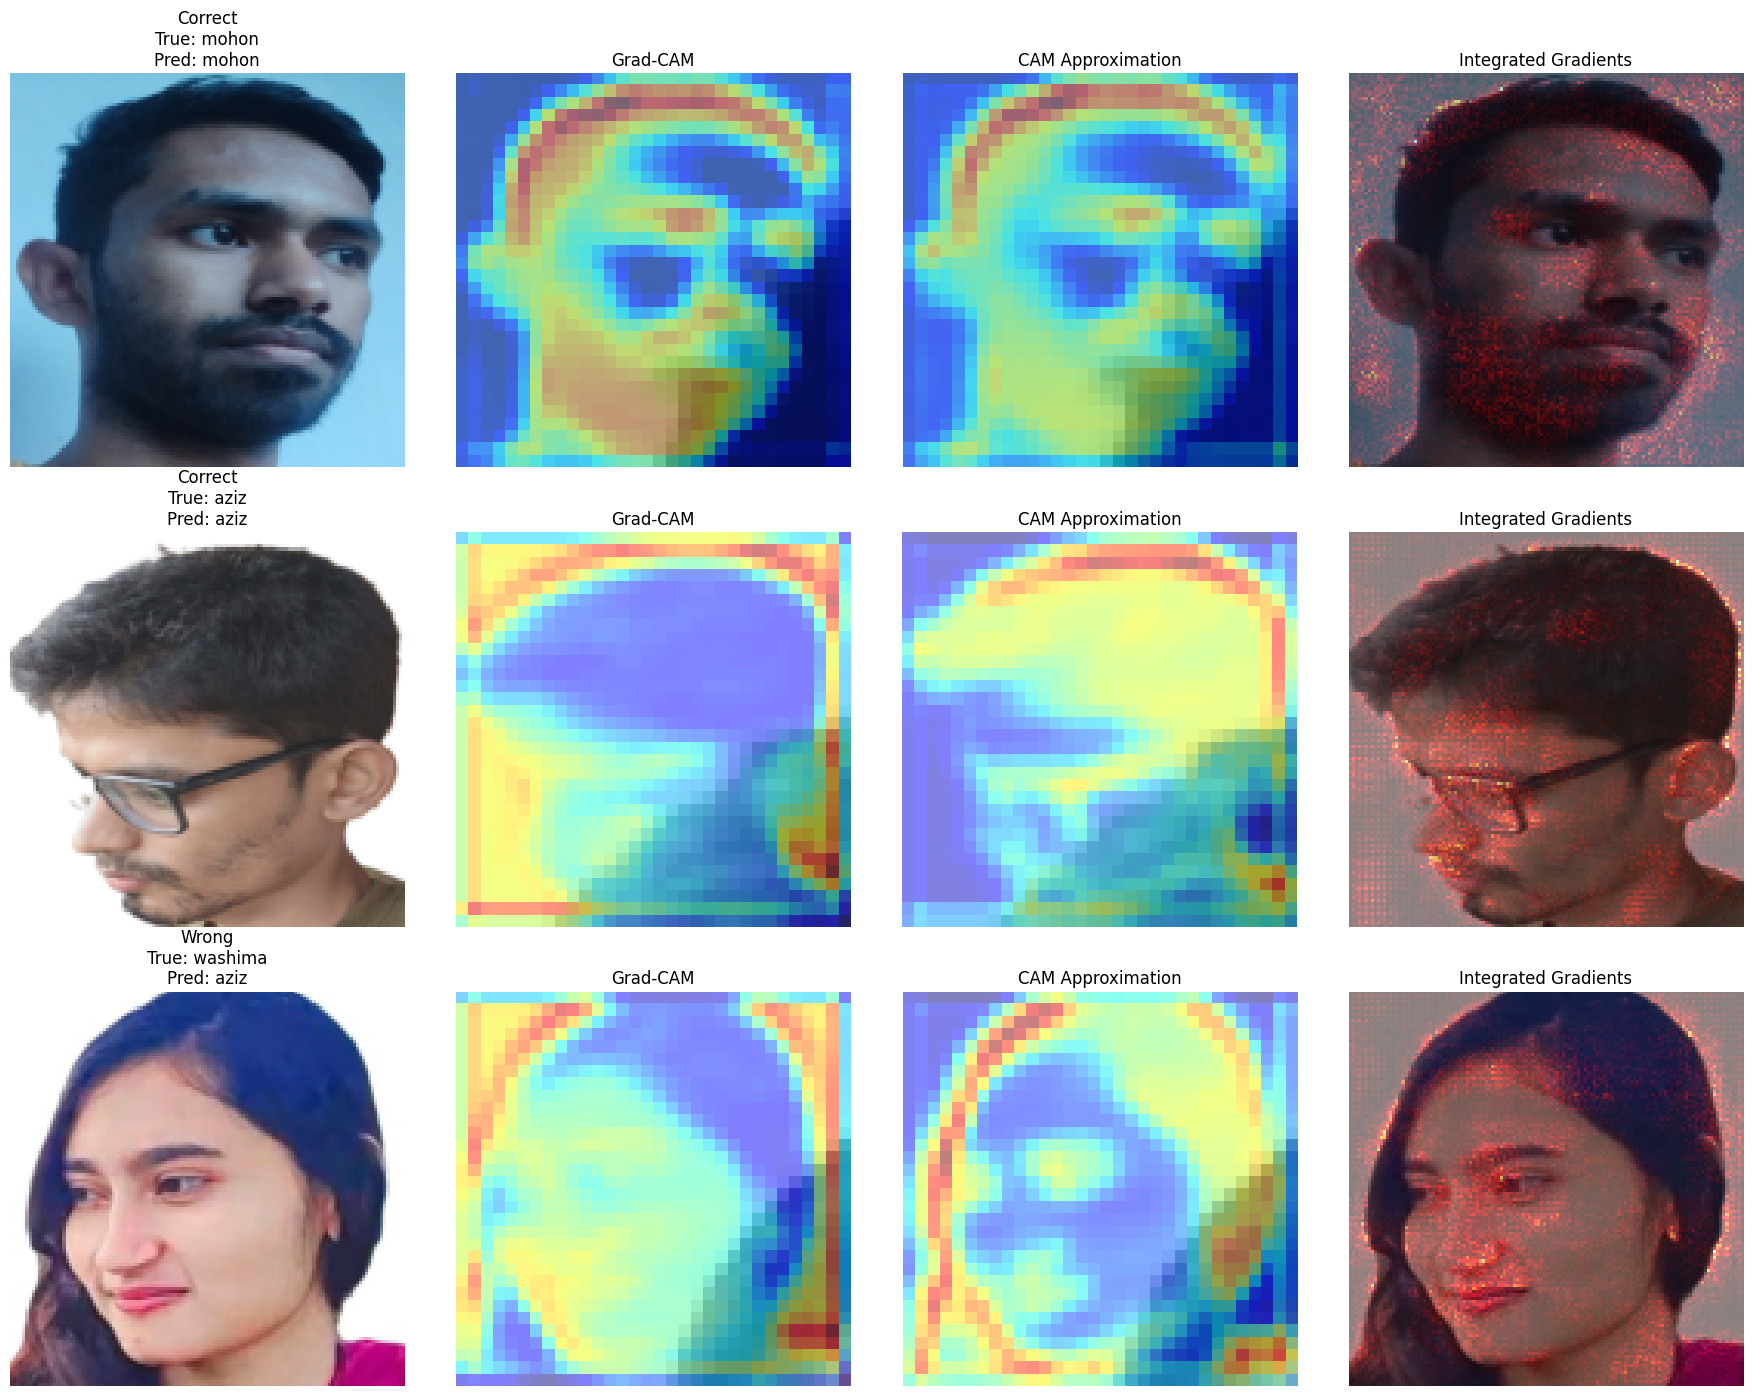

In [4]:
# ==========================================================
# FIND 2 CORRECT + 1 WRONG PREDICTIONS
# ==========================================================

model.eval()

correct_samples = []
wrong_samples = []

for image, label in test_loader:

    image = image.to(device)

    with torch.no_grad():

        output = model(image)

        pred = torch.argmax(output, dim=1).item()

    true_label = label.item()

    if pred == true_label and len(correct_samples) < 2:
        correct_samples.append((image, true_label, pred))

    if pred != true_label and len(wrong_samples) < 1:
        wrong_samples.append((image, true_label, pred))

    if len(correct_samples) == 2 and len(wrong_samples) == 1:
        break

samples = correct_samples + wrong_samples

# ==========================================================
# VISUALIZATION
# ==========================================================

fig, axes = plt.subplots(3,4, figsize=(18,14))

for idx, (image, true_lbl, pred_lbl) in enumerate(samples):

    img_np = image.squeeze().permute(1,2,0).cpu().numpy()

    true_name = class_names[true_lbl]
    pred_name = class_names[pred_lbl]

    # ======================================================
    # ORIGINAL
    # ======================================================
    axes[idx,0].imshow(img_np)

    result_text = "Correct" if true_lbl == pred_lbl else "Wrong"

    axes[idx,0].set_title(
        f"{result_text}\nTrue: {true_name}\nPred: {pred_name}"
    )

    axes[idx,0].axis("off")

    # ======================================================
    # GRAD-CAM
    # ======================================================
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_layer = model.features[6]

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(image)

    pred_class = output.argmax(dim=1)

    model.zero_grad()

    output[0, pred_class].backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)

    cam = (weights * acts).sum(dim=1).squeeze()

    cam = F.relu(cam)

    cam -= cam.min()

    cam /= cam.max()

    cam = cam.detach().cpu().numpy()

    axes[idx,1].imshow(img_np)
    axes[idx,1].imshow(cam, cmap='jet', alpha=0.5)
    axes[idx,1].set_title("Grad-CAM")
    axes[idx,1].axis("off")

    fh.remove()
    bh.remove()

    # ======================================================
    # CAM APPROXIMATION
    # ======================================================
    feature_maps = acts.squeeze().detach().cpu().numpy()

    avg_map = np.mean(feature_maps, axis=0)

    avg_map -= avg_map.min()
    avg_map /= avg_map.max()

    axes[idx,2].imshow(img_np)
    axes[idx,2].imshow(avg_map, cmap='jet', alpha=0.5)
    axes[idx,2].set_title("CAM Approximation")
    axes[idx,2].axis("off")

    # ======================================================
    # INTEGRATED GRADIENTS
    # ======================================================
    ig = IntegratedGradients(model)

    attributions, delta = ig.attribute(
        image,
        target=pred_class.item(),
        return_convergence_delta=True
    )

    attr = attributions.squeeze().cpu().detach().numpy()

    attr = np.transpose(attr, (1,2,0))

    attr = np.mean(np.abs(attr), axis=2)

    attr -= attr.min()

    attr /= attr.max()

    axes[idx,3].imshow(img_np)
    axes[idx,3].imshow(attr, cmap='hot', alpha=0.5)

    axes[idx,3].set_title("Integrated Gradients")

    axes[idx,3].axis("off")

plt.tight_layout()
plt.show()